# 1. Introduction

## 1.1 Dataset Overview

This dataset contains daily reports related to the humanitarian impact of the Gaza conflict that began on October 7, 2023. The data was obtained from the Tech for Palestine open-data platform and covers the period from October 7, 2023, to May 30, 2026.

The dataset includes a wide range of indicators related to the conflict, such as reported deaths, injuries, aid-seeker casualties, famine-related deaths, and casualties among specific professional groups including journalists, medical personnel, and civil defense workers. In addition, it contains information about infrastructure damage, including residential buildings, educational facilities, civic buildings, and places of worship.

Each record represents a reporting period and includes both official and extrapolated values, allowing the dataset to provide a continuous daily time series of humanitarian indicators throughout the conflict.

## 1.2 Data Source

The dataset used in this analysis was obtained from the Tech for Palestine open-data platform. The platform aggregates and publishes humanitarian indicators related to the Gaza conflict from official reporting sources. The dataset is available in multiple formats, including JSON, CSV, and API endpoints, making it accessible for data analysis and visualization tasks.

According to the dataset documentation, the data is updated regularly as new reports become available. The dataset includes information collected from multiple official sources and provides both reported and extrapolated values to maintain a continuous daily time series.


## 1.3 Project Objective

The objective of this project is to explore and understand the humanitarian impact reflected in the Gaza conflict dataset. Through data wrangling and exploratory data analysis, this project aims to examine trends, patterns, and relationships among reported casualties, injuries, humanitarian indicators, and infrastructure damage.

In addition to exploring the data itself, this project also seeks to assess data quality, identify potential limitations, and better understand the structure and reporting methodology used within the dataset. The findings will be summarized through visualizations and analytical observations to provide a clearer understanding of the reported indicators over time.

## 1.4 Analysis Questions

The following questions will guide the exploratory analysis of this dataset:

* Which periods experienced the highest numbers of reported deaths and injuries throughout the conflict?
* When did famine-related deaths begin to appear, and how did they evolve over time?
* Is there a temporal relationship between famine-related deaths and casualties among people seeking humanitarian aid?
* How has the destruction and damage of educational facilities evolved throughout the reporting period?
* What is the difference between the number of educational buildings reported as destroyed and those reported as damaged?
* Which category of infrastructure experienced the greatest level of destruction during the conflict?
* How have casualties among journalists, medical personnel, and civil defense workers changed over time?
* During which periods was the destruction of places of worship, particularly mosques, most significant?
* Are there observable relationships between casualty indicators and infrastructure damage indicators?
* How do official reported values compare with extrapolated values throughout the dataset?

# 2. Data Wrangling

## 2.1 Gather

The dataset used in this project was obtained from the Tech for Palestine open-data platform. The platform provides publicly accessible humanitarian datasets related to the Gaza conflict through downloadable files and API endpoints.

For this analysis, the data was retrieved from the official API and loaded into a pandas DataFrame for further processing. The original data was provided in JSON format and subsequently prepared for assessment and cleaning.

Source: https://data.techforpalestine.org/

Data Format: JSON (API Response)

Collection Method: API Retrieval

Time Coverage: October 7, 2023 – May 30, 2026


## 2.2 Assess

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/kaggle/input/datasets/ayaalharazin/gaza-humanitarian-impact-dataset-20232026/Gaza Casualties and Infrastructure Damage Dataset.csv')
df.head()

,report_date,report_source,report_period,ext_massacres_cum,killed,killed_cum,ext_killed,ext_killed_cum,ext_killed_children_cum,ext_killed_women_cum,...,places_of_worship.ext_mosques_damaged,places_of_worship.ext_churches_destroyed,residential.ext_destroyed,residential.destroyed,civic_buildings.destroyed,educational_buildings.destroyed,educational_buildings.damaged,places_of_worship.mosques_destroyed,places_of_worship.mosques_damaged,places_of_worship.churches_destroyed
0,10/7/2023,mohtel,24,0,232.0,232.0,232,232,0,0,...,4.0,0.0,80.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10/8/2023,mohtel,24,0,138.0,370.0,138,370,78,41,...,8.0,0.0,159.0,159.0,NaN,NaN,NaN,NaN,NaN,NaN
2,10/9/2023,mohtel,24,8,190.0,560.0,190,560,91,61,...,12.0,0.0,790.0,790.0,NaN,NaN,NaN,NaN,NaN,NaN
3,10/10/2023,mohtel,24,8,340.0,900.0,340,900,260,230,...,17.0,0.0,1009.0,1009.0,NaN,NaN,NaN,NaN,NaN,NaN
4,10/11/2023,gmotel,24,23,200.0,1100.0,200,1100,398,230,...,21.0,0.0,2835.0,2835.0,27.0,3.0,75.0,10.0,NaN,NaN


In [3]:
df.shape

(967, 39)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 967 entries, 0 to 966
Data columns (total 39 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   report_date                               967 non-null    object 
 1   report_source                             967 non-null    object 
 2   report_period                             967 non-null    int64  
 3   ext_massacres_cum                         967 non-null    int64  
 4   killed                                    940 non-null    float64
 5   killed_cum                                960 non-null    float64
 6   ext_killed                                967 non-null    int64  
 7   ext_killed_cum                            967 non-null    int64  
 8   ext_killed_children_cum                   967 non-null    int64  
 9   ext_killed_women_cum                      967 non-null    int64  
 10  injured_cum                           

In [5]:
df.describe()

,report_period,ext_massacres_cum,killed,killed_cum,ext_killed,ext_killed_cum,ext_killed_children_cum,ext_killed_women_cum,injured_cum,ext_injured,...,places_of_worship.ext_mosques_damaged,places_of_worship.ext_churches_destroyed,residential.ext_destroyed,residential.destroyed,civic_buildings.destroyed,educational_buildings.destroyed,educational_buildings.damaged,places_of_worship.mosques_destroyed,places_of_worship.mosques_damaged,places_of_worship.churches_destroyed
count,967.000000,967.000000,940.000000,960.000000,967.000000,967.000000,967.000000,967.000000,952.000000,967.000000,...,701.000000,730.000000,730.000000,111.000000,87.000000,94.000000,95.000000,86.000000,70.000000,88.0
mean,23.975181,7444.841779,72.747872,48404.812500,75.427094,48176.414685,16464.692865,10843.122027,115972.449580,178.820062,...,216.646220,2.884932,155675.967123,96203.810811,171.448276,102.723404,302.684211,426.418605,235.157143,3.0
std,10.388689,4520.821845,100.120945,18157.297685,105.572837,18290.700849,4351.093244,2718.873873,43741.090992,273.809648,...,46.710633,0.477669,94854.760887,70840.929385,38.872110,30.622012,55.734794,282.290525,43.384909,0.0
min,0.000000,0.000000,0.000000,232.000000,0.000000,232.000000,0.000000,0.000000,1610.000000,0.000000,...,4.000000,0.000000,80.000000,159.000000,27.000000,3.000000,75.000000,10.000000,145.000000,3.0
25%,24.000000,3260.000000,10.000000,37114.000000,10.000000,36568.000000,15348.000000,10231.000000,85273.500000,15.000000,...,212.000000,3.000000,70000.000000,52250.000000,136.000000,94.250000,295.000000,161.000000,200.000000,3.0
50%,24.000000,10100.000000,45.000000,47546.000000,46.000000,47487.000000,17861.000000,12316.000000,111639.000000,104.000000,...,214.000000,3.000000,150000.000000,70000.000000,184.000000,103.000000,309.000000,245.000000,214.000000,3.0
75%,24.000000,12000.000000,86.250000,66240.750000,88.000000,66122.500000,20000.000000,12500.000000,169468.250000,222.500000,...,214.000000,3.000000,165000.000000,150000.000000,199.500000,121.750000,333.500000,610.750000,266.000000,3.0
max,96.000000,12000.000000,786.000000,72938.000000,828.000000,72938.000000,20179.000000,12500.000000,172919.000000,3652.000000,...,326.000000,3.000000,416000.000000,416000.000000,247.000000,165.000000,392.000000,835.000000,326.000000,3.0


In [6]:
df[df.duplicated()]

,report_date,report_source,report_period,ext_massacres_cum,killed,killed_cum,ext_killed,ext_killed_cum,ext_killed_children_cum,ext_killed_women_cum,...,places_of_worship.ext_mosques_damaged,places_of_worship.ext_churches_destroyed,residential.ext_destroyed,residential.destroyed,civic_buildings.destroyed,educational_buildings.destroyed,educational_buildings.damaged,places_of_worship.mosques_destroyed,places_of_worship.mosques_damaged,places_of_worship.churches_destroyed


## 2.3 Quality Issues

The following potential data quality issues were identified during the assessment phase and will be evaluated during data cleaning:

* The report_date column is stored as an object rather than a datetime data type.
* Some observations contain zero values in the ext_killed column while the cumulative death count (ext_killed_cum) continues to increase. This suggests that certain zero values may not represent true zero-casualty periods and could instead reflect reporting inconsistencies or missing daily values.

## 2.4 Tidiness Issues
After assessing the dataset structure, no major tidiness issues were identified. Each row represents a single reporting period, each column represents a distinct variable, and each cell contains a single value. Therefore, the dataset largely conforms to tidy data principles.

Any transformations performed during cleaning will focus primarily on data quality rather than dataset tidiness.

## 2.5 Cleaning

Issue #1: report_date Stored as Object
Define

Convert the report_date column from the object data type to a proper datetime format to enable time-series analysis and date-based operations.

In [7]:
df['report_date'] = pd.to_datetime(df['report_date'])
df.set_index('report_date', inplace=True)
df.head()

,report_source,report_period,ext_massacres_cum,killed,killed_cum,ext_killed,ext_killed_cum,ext_killed_children_cum,ext_killed_women_cum,injured_cum,...,places_of_worship.ext_mosques_damaged,places_of_worship.ext_churches_destroyed,residential.ext_destroyed,residential.destroyed,civic_buildings.destroyed,educational_buildings.destroyed,educational_buildings.damaged,places_of_worship.mosques_destroyed,places_of_worship.mosques_damaged,places_of_worship.churches_destroyed
report_date,,,,,,,,,,,,,,,,,,,,,
2023-10-07,mohtel,24,0,232.0,232.0,232,232,0,0,1610.0,...,4.0,0.0,80.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-08,mohtel,24,0,138.0,370.0,138,370,78,41,1788.0,...,8.0,0.0,159.0,159.0,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-09,mohtel,24,8,190.0,560.0,190,560,91,61,2271.0,...,12.0,0.0,790.0,790.0,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-10,mohtel,24,8,340.0,900.0,340,900,260,230,4000.0,...,17.0,0.0,1009.0,1009.0,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-11,gmotel,24,23,200.0,1100.0,200,1100,398,230,5184.0,...,21.0,0.0,2835.0,2835.0,27.0,3.0,75.0,10.0,NaN,NaN


# 3. Exploratory Data Analysis

In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

## 3.1 Univariate Analysis

### A. Metadata
**conclusion**
The metadata analysis provides important context about the structure and reporting process of the dataset.

The report_source distribution shows that the vast majority of records originate from the Ministry of Health (mohtel), indicating that it serves as the primary source of humanitarian reporting within the dataset. Reports from the Government Media Office (gmotel) are relatively limited, while only a small number of records have an unspecified source (missing).

Analysis of the report_period variable reveals that most records correspond to 24-hour reporting periods, suggesting that the dataset primarily consists of daily reports. A smaller number of observations represent longer reporting intervals, including 48-hour, 72-hour, and 96-hour periods. Additionally, some records have a reporting period of 0 hours, which may indicate special reporting circumstances or missing reporting-period information.

Overall, the metadata indicates that the dataset is largely composed of daily reports collected from a dominant reporting source, providing a consistent time-series structure suitable for trend analysis and longitudinal studies.

In [9]:
df['report_source'].describe()

count        967
unique         3
top       mohtel
freq         933
Name: report_source, dtype: object

<Axes: xlabel='report_source'>

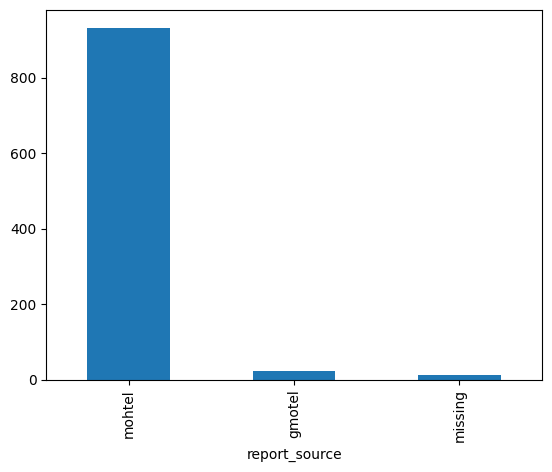

In [10]:
df['report_source'].value_counts().plot(kind = 'bar')

<Axes: xlabel='report_period'>

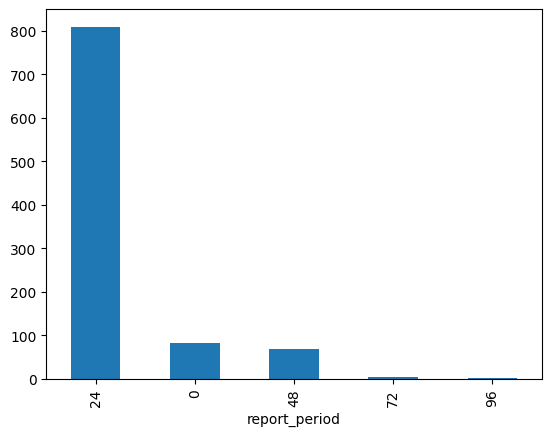

In [11]:
df['report_period'].value_counts().plot(kind = 'bar')

### B. Daily Casualties
**conclusion**
* Daily reported deaths were highest during the early months of the conflict (late 2023), followed by a general decline in average daily fatalities over time; however, several major spikes reappeared throughout 2025, indicating that periods of intensified violence continued despite the overall downward trend.
* The distribution of daily reported deaths is highly right-skewed, with most reporting periods recording relatively low casualty counts (generally below 100 deaths). The median daily death count is approximately 45 deaths, while numerous extreme outliers extend beyond 200 deaths and reach nearly 800 deaths. This indicates that although most days experienced lower casualty levels, a limited number of reporting periods were associated with exceptionally high death tolls, substantially increasing the overall average and reflecting periods of intensified violence.
* Women and children account for a substantial share of the total reported deaths, representing 17.1% and 27.7% of all fatalities respectively. Together, they constitute approximately 44.8% of the total reported deaths. The remaining 55.2% are classified as Others, which likely includes adult men, elderly individuals, and casualties whose demographic category is not explicitly identified in the dataset. This distribution highlights that the impact of the conflict extends across multiple segments of the population, with a significant proportion of reported fatalities occurring among civilians, including women and children.
* Daily reported injuries reached their highest levels during the first months of the conflict, with several reporting periods exceeding 3,000 injuries. Injury counts gradually declined afterward, although additional spikes were observed during 2025. The concentration of injuries in the early stages of the conflict indicates that the humanitarian impact was particularly severe during that period.
* The cumulative number of famine-related deaths and aid-seeker deaths increased rapidly during the same general period in mid-to-late 2025, suggesting a worsening humanitarian situation. Notably, famine-related deaths began increasing before aid-seeker deaths reached their sharpest growth phase. While the dataset does not establish a causal relationship, the temporal pattern may indicate that deteriorating food security conditions coincided with an increase in casualties among individuals seeking humanitarian assistance. By October 2025, both indicators had largely stabilized, reaching approximately 463 famine-related deaths and 2,615 aid-seeker deaths.

In [12]:
df['killed'].describe()

count    940.000000
mean      72.747872
std      100.120945
min        0.000000
25%       10.000000
50%       45.000000
75%       86.250000
max      786.000000
Name: killed, dtype: float64

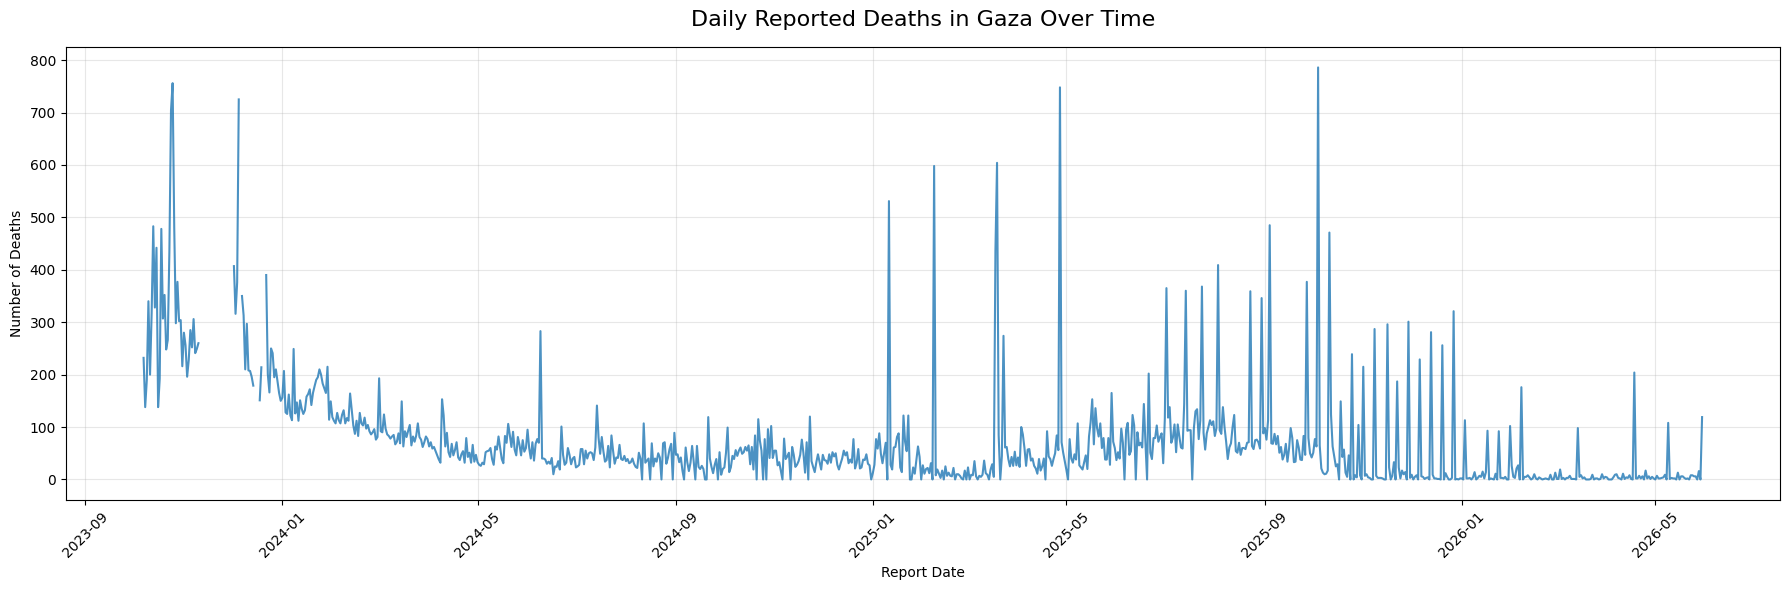

In [13]:
fig, ax = plt.subplots(figsize=(18, 6))

ax.plot(
    df.index,
    df['killed'],
    linewidth=1.5,
    alpha=0.8
)

ax.set_title('Daily Reported Deaths in Gaza Over Time', fontsize=16, pad=15)
ax.set_xlabel('Report Date')
ax.set_ylabel('Number of Deaths')

plt.xticks(rotation=45)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
df['killed'].isna().sum()

np.int64(27)

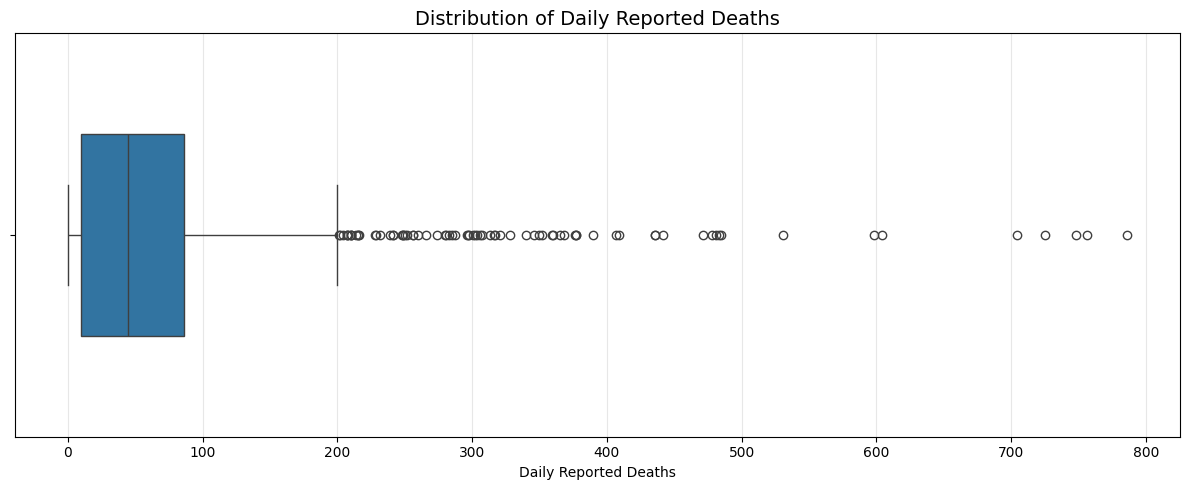

In [15]:
plt.figure(figsize=(12, 5))

sns.boxplot(
    x=df['killed'],
    width=0.5
)

plt.title('Distribution of Daily Reported Deaths', fontsize=14)
plt.xlabel('Daily Reported Deaths')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

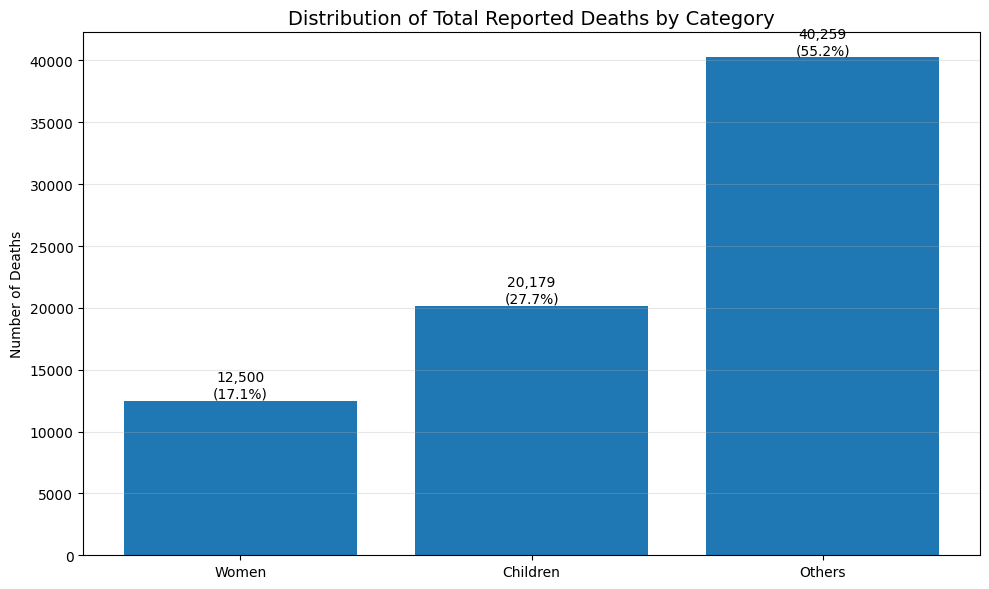

Women: 17.14%
Children: 27.67%
Women and Children Combined: 44.80%


In [16]:
# Get latest cumulative values
total_martyrs = df['ext_killed_cum'].iloc[-1]
children_martyrs = df['ext_killed_children_cum'].iloc[-1]
women_martyrs = df['ext_killed_women_cum'].iloc[-1]

# Calculate remaining deaths
other_martyrs = total_martyrs - women_martyrs - children_martyrs

# Categories and values
categories = ['Women', 'Children', 'Others']
values = [women_martyrs, children_martyrs, other_martyrs]

# Percentages
percentages = [value / total_martyrs * 100 for value in values]

# Plot
plt.figure(figsize=(10, 6))

bars = plt.bar(categories, values)

# Add value and percentage labels
for bar, value, pct in zip(bars, values, percentages):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{value:,.0f}\n({pct:.1f}%)',
        ha='center',
        va='bottom'
    )

plt.title('Distribution of Total Reported Deaths by Category', fontsize=14)
plt.ylabel('Number of Deaths')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
women_pct = women_martyrs / total_martyrs * 100
children_pct = children_martyrs / total_martyrs * 100
women_children_pct = (women_martyrs + children_martyrs) / total_martyrs * 100

print(f"Women: {women_pct:.2f}%")
print(f"Children: {children_pct:.2f}%")
print(f"Women and Children Combined: {women_children_pct:.2f}%")

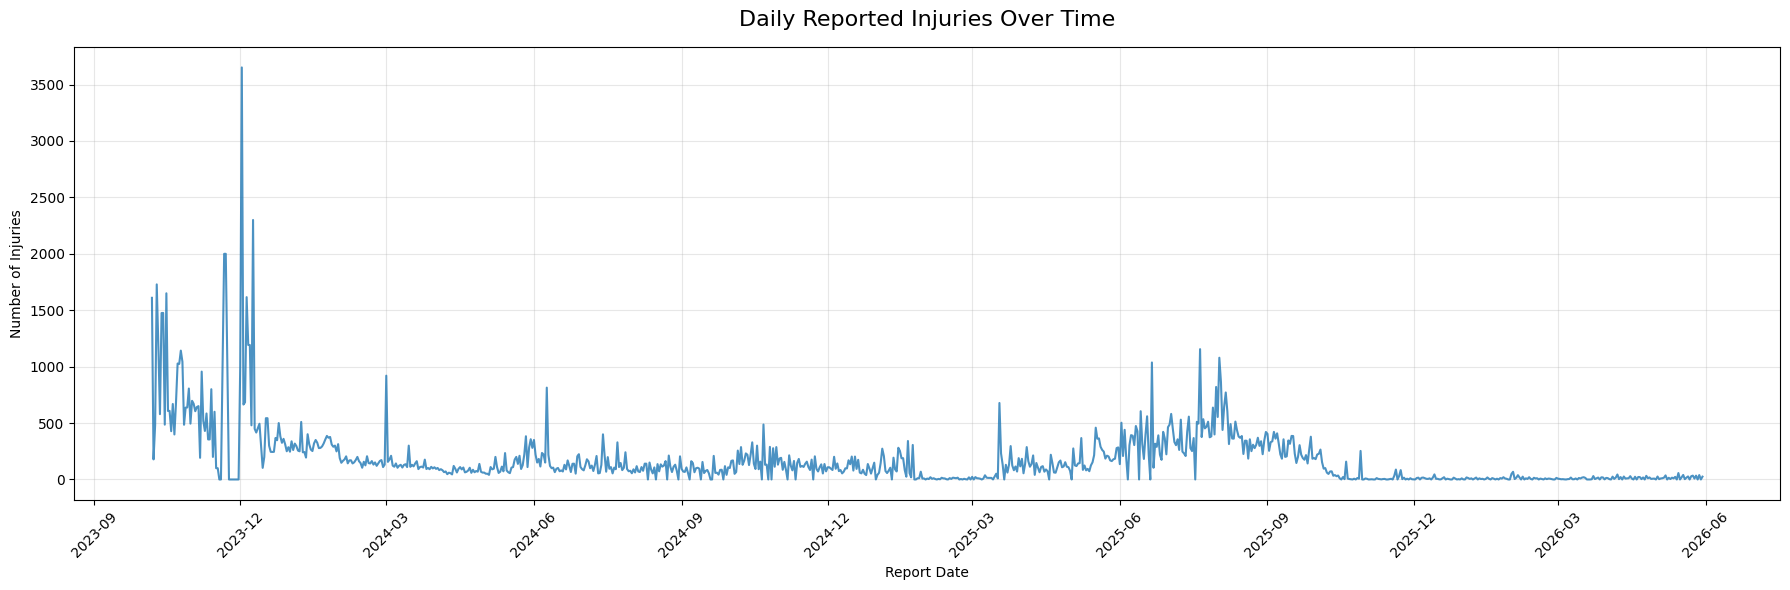

In [17]:
fig, ax = plt.subplots(figsize=(18, 6))

ax.plot(
    df.index,
    df['ext_injured'],
    linewidth=1.5,
    alpha=0.8
)

ax.set_title('Daily Reported Injuries Over Time', fontsize=16, pad=15)
ax.set_xlabel('Report Date')
ax.set_ylabel('Number of Injuries')

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

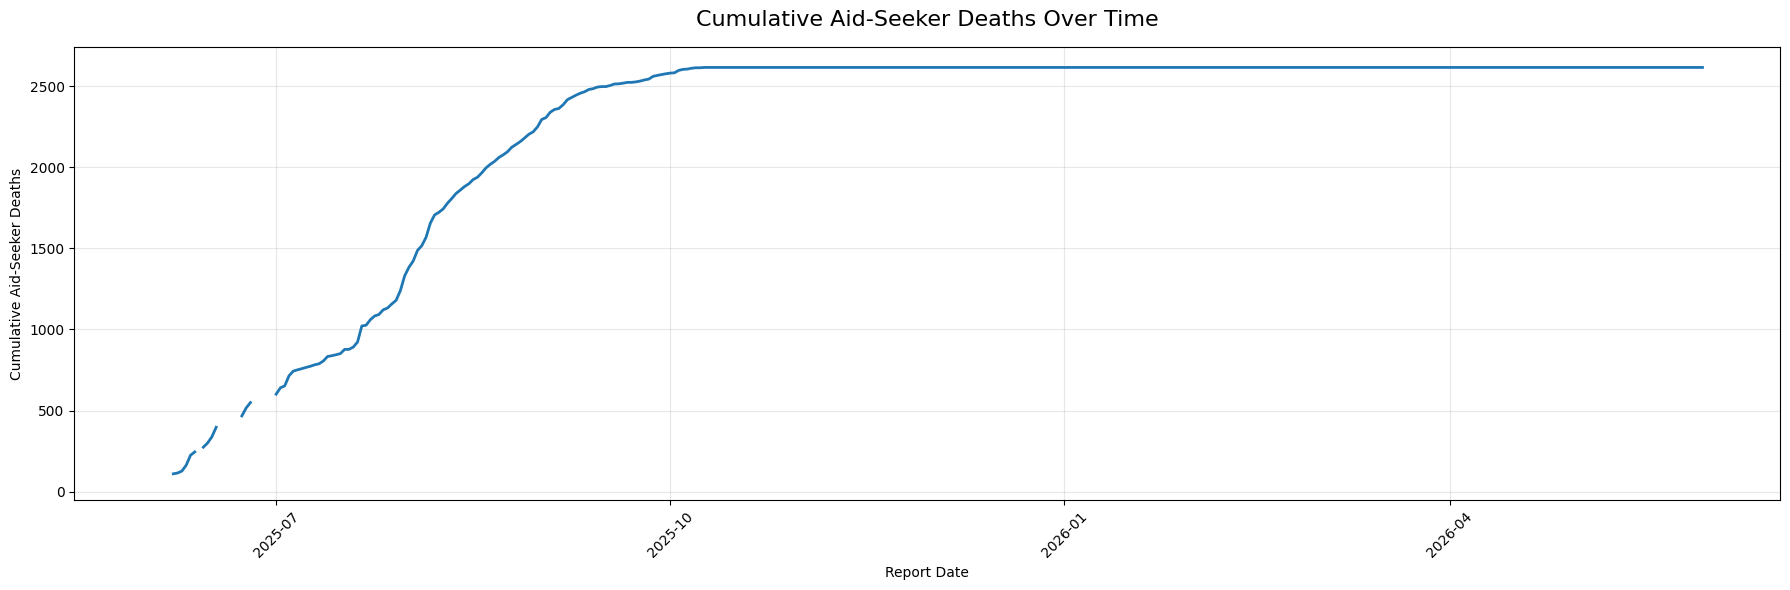

In [18]:
fig, ax = plt.subplots(figsize=(18, 6))

ax.plot(
    df.index,
    df['aid_seeker_killed_cum'],
    linewidth=2
)

ax.set_title('Cumulative Aid-Seeker Deaths Over Time', fontsize=16, pad=15)
ax.set_xlabel('Report Date')
ax.set_ylabel('Cumulative Aid-Seeker Deaths')

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

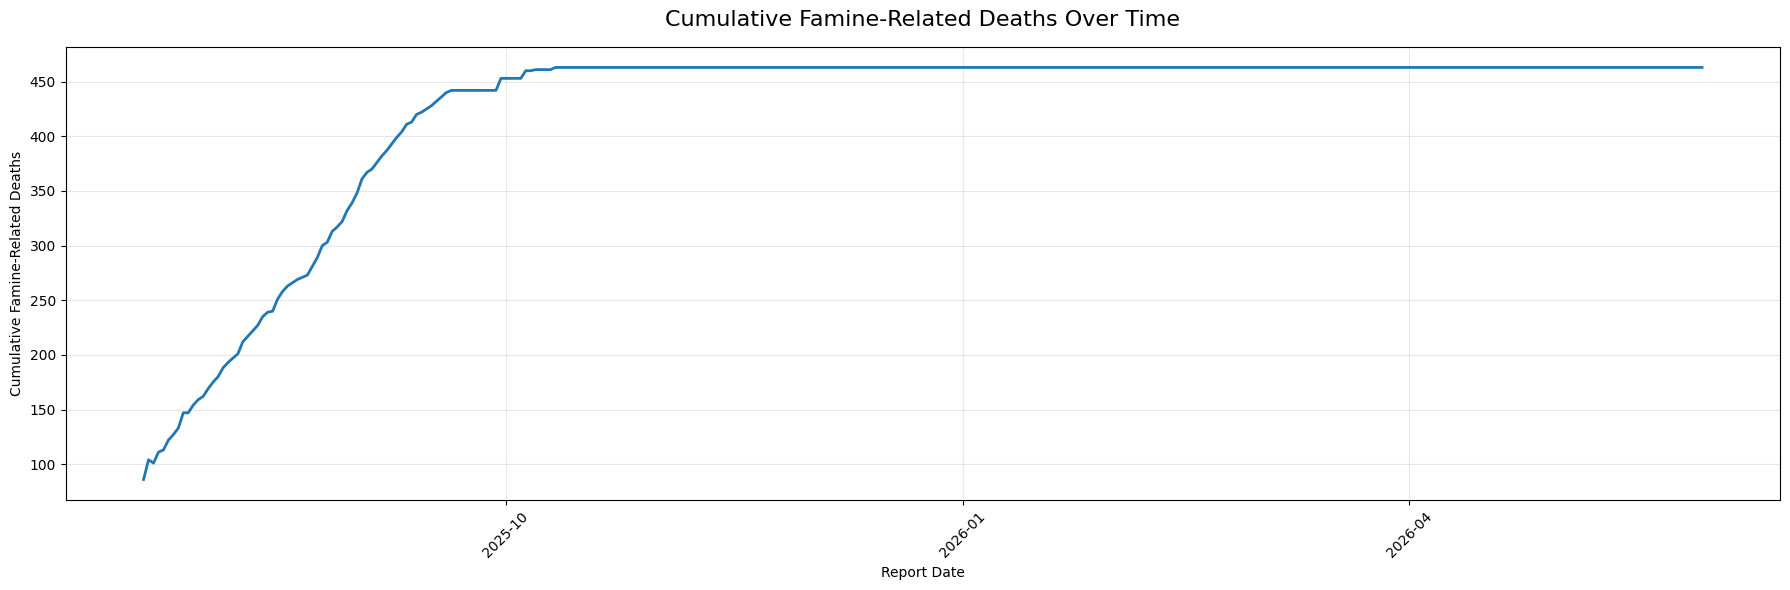

In [19]:
fig, ax = plt.subplots(figsize=(18, 6))

ax.plot(
    df.index,
    df['famine_cum'],
    linewidth=2
)

ax.set_title('Cumulative Famine-Related Deaths Over Time', fontsize=16, pad=15)
ax.set_xlabel('Report Date')
ax.set_ylabel('Cumulative Famine-Related Deaths')

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3.3 Bivariate Analysis

### 3.3.1 Famine Deaths vs Aid-Seeker Deaths
**conclusion**
* Both famine-related deaths and aid-seeker deaths increased sharply during the same period, primarily between July and October 2025, indicating a deterioration in humanitarian conditions.
Aid-seeker deaths grew at a substantially faster rate than famine-related deaths, reaching approximately 2,620 deaths compared to 462 famine-related deaths by the end of the reporting period.
* The rise in famine-related deaths preceded and overlapped with the rapid increase in aid-seeker deaths, suggesting that worsening food insecurity and the risks associated with obtaining humanitarian assistance emerged simultaneously.
* After October 2025, both indicators stabilized and showed little to no further growth, indicating that the majority of reported famine-related and aid-seeker deaths occurred within a relatively short time frame.

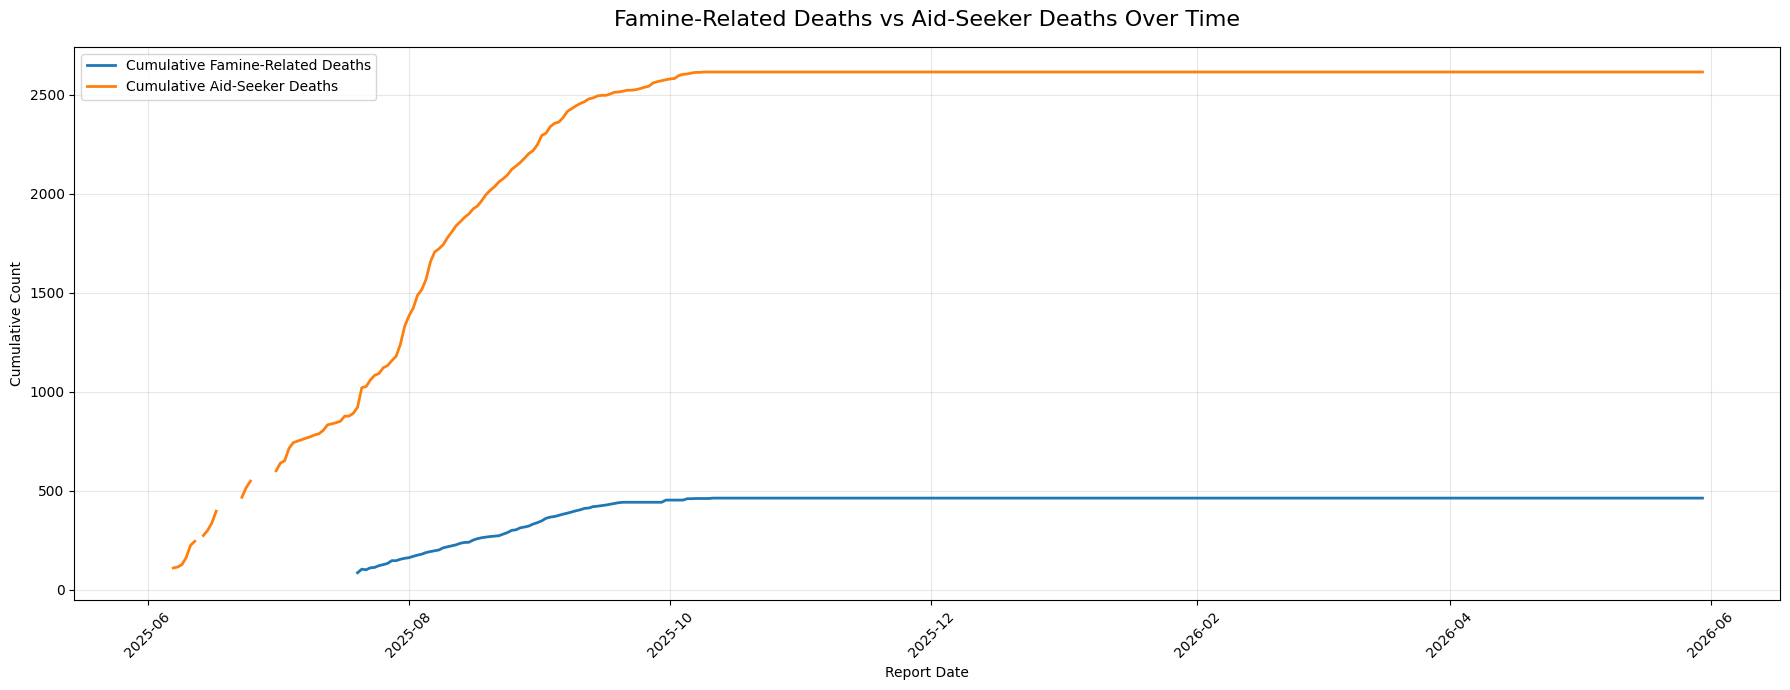

In [20]:
plt.figure(figsize=(18, 7))

plt.plot(
    df.index,
    df['famine_cum'],
    linewidth=2,
    label='Cumulative Famine-Related Deaths'
)

plt.plot(
    df.index,
    df['aid_seeker_killed_cum'],
    linewidth=2,
    label='Cumulative Aid-Seeker Deaths'
)

plt.title(
    'Famine-Related Deaths vs Aid-Seeker Deaths Over Time',
    fontsize=16,
    pad=15
)

plt.xlabel('Report Date')
plt.ylabel('Cumulative Count')

plt.legend()

plt.grid(alpha=0.3)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 3.3.2 Deaths vs Injuries with Year
**conclusion**
The relationship between daily deaths and daily injuries remained consistently positive throughout the conflict; however, the most extreme casualty events were concentrated in 2023, while subsequent years generally exhibited lower daily casualty levels despite occasional spikes.

<Axes: xlabel='ext_killed', ylabel='ext_injured'>

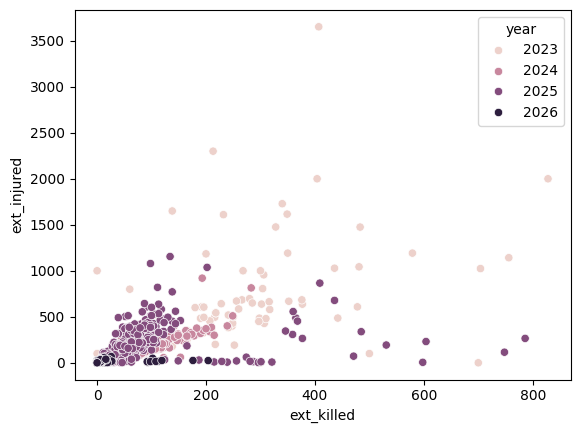

In [21]:
df['year'] = df.index.year
sns.scatterplot(
    data=df,
    x='ext_killed',
    y='ext_injured',
    hue='year'
)

## 4. Final Thoughts

This analysis explored casualty, humanitarian, and infrastructure-related data from the Gaza conflict between October 2023 and May 2026. Through exploratory data analysis, we identified patterns in deaths, injuries, famine-related casualties, aid-seeker deaths, and the destruction of critical infrastructure.

While visualizations, statistics, and correlations help us understand trends within the data, it is important to remember that these figures represent far more than numbers on a chart. Behind every data point is a human story—a person with dreams, aspirations, a family, and a future that was altered or lost.

The thousands of reported deaths and injuries documented in this dataset reflect profound human suffering. The destruction of homes, schools, places of worship, and other essential infrastructure extends the impact beyond individuals to entire communities and future generations.

Data analysis can help us better understand the scale and evolution of humanitarian crises, but it should also remind us of the human lives behind the statistics. Ultimately, this notebook is not only about exploring data; it is about recognizing the human cost represented by every observation in the dataset.